In [1]:
import numpy as np
from scipy import linalg
import time
import matplotlib.pyplot as plt


def _calc_branch_message_rescaled(id, current_pos, branch_above, transition_matrices):
    """Calculates the message to be passed along a branch above specified node

    Parameters
    ----------
    id : int
        ID of node
    current_pos : np.array
        Probability distribution of node's current position given subtree below
    branch_above : np.array
        Branch lengths above each node split across epochs
    transition_matrices : np.array
        Rate matrices for each epoch

    Returns
    -------
    message : np.array
        Probability distribution for location of lineage given subtree below
    """

    bl = branch_above[:,id]
    included_epochs = np.where(bl > 0)[0]
    for epoch in included_epochs:
        current_pos = scipy.sparse.linalg.expm_multiply(transition_matrices[epoch]*bl[epoch], current_pos)
    return current_pos

def likelihood_of_tree_rescaled(
        parents,
        branch_above,
        ids_asc_time,
        sample_locations_array,
        sample_ids,
        transition_matrices
    ):

    num_demes = len(sample_locations_array[0])
    messages = np.zeros((len(parents), num_demes), dtype="float64")
    loglikelihood = 0
    for id in ids_asc_time: 
        
        if id in sample_ids:
            current_pos = sample_locations_array[np.where(sample_ids==id)[0][0]]
        else:
            current_pos = _calc_current_pos(
                id,
                messages,
                parents
            )
        
        s = np.sum(current_pos)
        current_pos /= s
        loglikelihood += np.log(s)
        
        parent = parents[id]
        if parent != -1:
            messages[id] = _calc_branch_message_rescaled(
                id,
                current_pos,
                branch_above,
                transition_matrices
            )
        else:   # collect roots here
            messages[id] = current_pos

    return loglikelihood, messages

In [2]:
import numpy as np
from scipy import linalg
import time
import matplotlib.pyplot as plt


def plot_messages(messages, save_to=None):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
    ax[0].bar(range(len(messages[0])), messages[0], width=1, color="#E95E0D", alpha=0.5)
    ax[0].bar(range(len(messages[1])), messages[1], width=1, alpha=0.5)
    ax[1].bar(range(len(messages[2])), messages[2], width=1, color="#000000")
    if save_to is not None:
        plt.savefig(save_to)
    plt.show()

def _calc_current_pos(id, messages, parents):
    """Calculates current node position as product of child messages

    Parameters
    ----------
    id : int
        ID of node
    messages : np.array
        Messages being passed in tree
    parents : np.array
        Parent IDs for each node
    
    Returns
    -------
    current_pos : np.array
        Probability distribution of node's current position given subtree below
    """

    return np.prod(messages[np.where(parents==id)[0]], axis=0)

def _calc_branch_message(id, current_pos, branch_above, transition_matrices):
    """Calculates the message to be passed along a branch above specified node

    Parameters
    ----------
    id : int
        ID of node
    current_pos : np.array
        Probability distribution of node's current position given subtree below
    branch_above : np.array
        Branch lengths above each node split across epochs
    transition_matrices : np.array
        Rate matrices for each epoch

    Returns
    -------
    message : np.array
        Probability distribution for location of lineage given subtree below
    """

    bl = branch_above[:,id]
    included_epochs = np.where(bl > 0)[0]
    P = np.eye(len(current_pos))
    for epoch in included_epochs:
        P = np.dot(P, linalg.expm(transition_matrices[epoch]*bl[epoch]))
    message = np.dot(current_pos, P)
    return message

def likelihood_of_tree(
        parents,
        branch_above,
        ids_asc_time,
        sample_locations_array,
        sample_ids,
        transition_matrices
    ):
    """

    Parameters
    ----------
    parents : np.array
        Parent IDs for each node
    branch_above : np.array
        Branch lengths above each node split across epochs
    ids_asc_time : np.array
        Nodes IDs in time ascending order
    sample_locations_array : np.array
        Array
    sample_ids : np.array
        Defines order of sample node IDs for sample_locations_array
    transition_matrices : np.array
        Rate matrices for each epoch

    Returns
    -------
    loglikelihood : float
        Log-likelihood of tree
    """

    num_demes = len(sample_locations_array[0])
    messages = np.zeros((len(parents), num_demes), dtype="float64")
    loglikelihood = 0
    for id in ids_asc_time: 
        if id in sample_ids:
            current_pos = sample_locations_array[np.where(sample_ids==id)[0][0]]
        else:
            current_pos = _calc_current_pos(
                id,
                messages,
                parents
            )
        parent = parents[id]
        if parent != -1:
            messages[id] = _calc_branch_message(
                id,
                current_pos,
                branch_above,
                transition_matrices
            )
        else:   # collect roots here
            messages[id] = current_pos
            loglikelihood += np.log(np.sum(current_pos))
    return loglikelihood, messages

In [3]:
ids_asc_time = np.array([0, 1, 2])
parents = np.array([2, 2, -1])
branch_above = np.array([[1, 1, 0]])
sample_locations_array = np.array([
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
])
sample_ids = np.array([0, 1])
#s = np.array([1.0, 0.8, 0.6, 0.4, 0.2, 0.2, 0.4, 0.6, 0.8, 1.0])
s = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
#s = np.array([1/512, 1/256, 1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1/1])

/var/folders/q7/rz2nckpx02s10jlx05wbk6c00000gn/T/ipykernel_69427/4218186473.py:117: RuntimeWarning: divide by zero encountered in log
  loglikelihood += np.log(np.sum(current_pos))


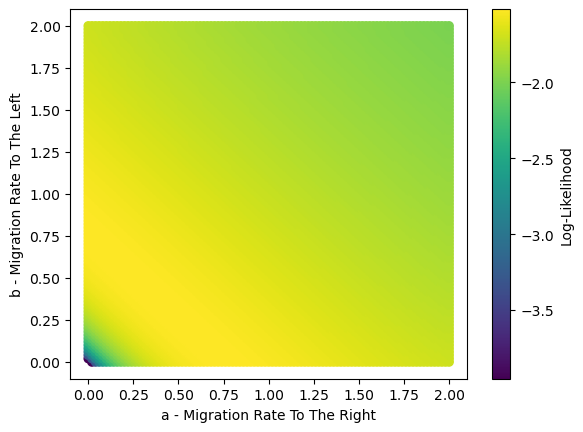

In [4]:
loglikelihoods = []
ms = []
ns = []

for a in range(0, 101):
    for b in range(0, 101):

        m = a / 50
        n = b / 50
    
        transition_matrices = np.array([
            [
                [-m, m, 0, 0, 0, 0, 0, 0, 0, 0],
                [n, -(m+n), m, 0, 0, 0, 0, 0, 0, 0],
                [0, n, -(m+n), m, 0, 0, 0, 0, 0, 0],
                [0, 0, n, -(m+n), m, 0, 0, 0, 0, 0],
                [0, 0, 0, n, -(m+n), m, 0, 0, 0, 0],
                [0, 0, 0, 0, n, -(m+n), m, 0, 0, 0],
                [0, 0, 0, 0, 0, n, -(m+n), m, 0, 0],
                [0, 0, 0, 0, 0, 0, n, -(m+n), m, 0],
                [0, 0, 0, 0, 0, 0, 0, n, -(m+n), m],
                [0, 0, 0, 0, 0, 0, 0, 0, n, -n]
            ]
        ])
        
        like, messages = likelihood_of_tree(
            parents,
            branch_above,
            ids_asc_time,
            sample_locations_array,
            sample_ids,
            transition_matrices
        )

        ms.append(m)
        ns.append(n)
        loglikelihoods.append(like)

plt.scatter(ms, ns, c=loglikelihoods)
plt.colorbar(label="Log-Likelihood")
plt.xlabel("a - Migration Rate To The Right")
plt.ylabel("b - Migration Rate To The Left")
#plt.savefig("figures/asymmetric_likelihood_surface_bottom_left_45.png")
plt.show()

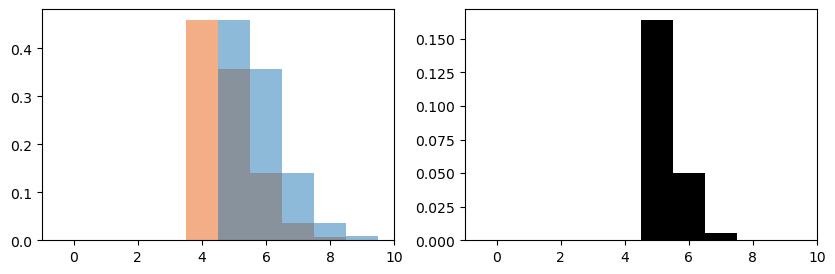

In [5]:
m = 0.78
n = 0.00

transition_matrices = np.array([
    [
        [-m, m, 0, 0, 0, 0, 0, 0, 0, 0],
        [n, -(m+n), m, 0, 0, 0, 0, 0, 0, 0],
        [0, n, -(m+n), m, 0, 0, 0, 0, 0, 0],
        [0, 0, n, -(m+n), m, 0, 0, 0, 0, 0],
        [0, 0, 0, n, -(m+n), m, 0, 0, 0, 0],
        [0, 0, 0, 0, n, -(m+n), m, 0, 0, 0],
        [0, 0, 0, 0, 0, n, -(m+n), m, 0, 0],
        [0, 0, 0, 0, 0, 0, n, -(m+n), m, 0],
        [0, 0, 0, 0, 0, 0, 0, n, -(m+n), m],
        [0, 0, 0, 0, 0, 0, 0, 0, n, -n]
    ]
])

like, messages = likelihood_of_tree(
    parents,
    branch_above,
    ids_asc_time,
    sample_locations_array,
    sample_ids,
    transition_matrices
)

plot_messages(messages)

/var/folders/q7/rz2nckpx02s10jlx05wbk6c00000gn/T/ipykernel_69427/4218186473.py:117: RuntimeWarning: divide by zero encountered in log
  loglikelihood += np.log(np.sum(current_pos))


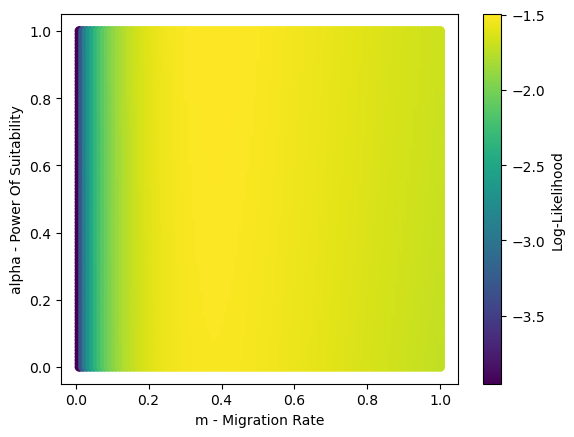

In [6]:
loglikelihoods = []
ms = []
ns = []

for a in range(0, 101):
    for b in range(0, 101):

        m = a / 100
        n = b / 100
    
        pi = s ** n
        
        transition_matrices = np.array([
            [
                [-(m*(pi[1]/pi[0])), m*(pi[1]/pi[0]), 0, 0, 0, 0, 0, 0, 0, 0],
                [m*(pi[0]/pi[1]), -(m*(pi[0]/pi[1])+m*(pi[2]/pi[1])), m*(pi[2]/pi[1]), 0, 0, 0, 0, 0, 0, 0],
                [0, m*(pi[1]/pi[2]), -(m*(pi[1]/pi[2])+m*(pi[3]/pi[2])), m*(pi[3]/pi[2]), 0, 0, 0, 0, 0, 0],
                [0, 0, m*(pi[2]/pi[3]), -(m*(pi[2]/pi[3])+m*(pi[4]/pi[3])), m*(pi[4]/pi[3]), 0, 0, 0, 0, 0],
                [0, 0, 0, m*(pi[3]/pi[4]), -(m*(pi[3]/pi[4])+m*(pi[5]/pi[4])), m*(pi[5]/pi[4]), 0, 0, 0, 0],
                [0, 0, 0, 0, m*(pi[4]/pi[5]), -(m*(pi[4]/pi[5])+m*(pi[6]/pi[5])), m*(pi[6]/pi[5]), 0, 0, 0],
                [0, 0, 0, 0, 0, m*(pi[5]/pi[6]), -(m*(pi[5]/pi[6])+m*(pi[7]/pi[6])), m*(pi[7]/pi[6]), 0, 0],
                [0, 0, 0, 0, 0, 0, m*(pi[6]/pi[7]), -(m*(pi[6]/pi[7])+m*(pi[8]/pi[7])), m*(pi[8]/pi[7]), 0],
                [0, 0, 0, 0, 0, 0, 0, m*(pi[7]/pi[8]), -(m*(pi[7]/pi[8])+m*(pi[9]/pi[8])), m*(pi[9]/pi[8])],
                [0, 0, 0, 0, 0, 0, 0, 0, m*(pi[8]/pi[9]), -(m*(pi[8]/pi[9]))]
            ]
        ])
        
        like, messages = likelihood_of_tree(
            parents,
            branch_above,
            ids_asc_time,
            sample_locations_array,
            sample_ids,
            transition_matrices
        )

        ms.append(m)
        ns.append(n)
        loglikelihoods.append(like)

plt.scatter(ms, ns, c=loglikelihoods)
plt.colorbar(label="Log-Likelihood")
plt.xlabel("m - Migration Rate")
plt.ylabel("alpha - Power Of Suitability")
#plt.savefig("figures/suitability_likelihood_surface_bottom_left_45.png")
plt.show()

In [7]:
print(ms[4039], ns[4039], loglikelihoods[4039], np.argmax(loglikelihoods)) #-4.0998090568947125

0.39 1.0 -1.497222173757427 4039


In [8]:
sorted(loglikelihoods, reverse=True)

[np.float64(-1.497222173757427),
 np.float64(-1.4973136291294085),
 np.float64(-1.4974233173043037),
 np.float64(-1.4974813407447116),
 np.float64(-1.4975143931533972),
 np.float64(-1.497624600743314),
 np.float64(-1.4976829687202773),
 np.float64(-1.497715345336803),
 np.float64(-1.4977272432666315),
 np.float64(-1.4978260251042388),
 np.float64(-1.4978846869205624),
 np.float64(-1.4979164867951507),
 np.float64(-1.497927729592106),
 np.float64(-1.4980275914396497),
 np.float64(-1.4980864962900744),
 np.float64(-1.4981178186666202),
 np.float64(-1.4981222059146448),
 np.float64(-1.4981284509851098),
 np.float64(-1.498229300824965),
 np.float64(-1.498288397796252),
 np.float64(-1.4983193421121026),
 np.float64(-1.4983244263342055),
 np.float64(-1.4983294086473804),
 np.float64(-1.498431154358503),
 np.float64(-1.4984369100914388),
 np.float64(-1.498490392429519),
 np.float64(-1.4985210583152582),
 np.float64(-1.4985266858696338),
 np.float64(-1.4985306038031798),
 np.float64(-1.4986331

[[[-3.99360000e+02  3.99360000e+02  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 3.80859375e-04 -2.24897461e+01  2.24893652e+01  0.00000000e+00
    0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  6.76319667e-03 -6.93227658e+00  6.92551339e+00
    0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  2.19622707e-02 -3.65412031e+00
    3.63215804e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  4.18759311e-02
   -2.45665314e+00  2.41477720e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    6.29871773e-02 -1.88492060e+00  1.82193342e+00  0.00000000e+00
    0.00000000e+

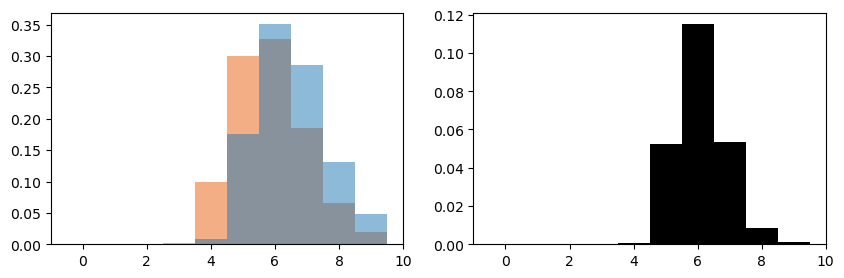

In [9]:
m = 0.39
pi = s ** 10.0

transition_matrices = np.array([
    [
        [-(m*(pi[1]/pi[0])), m*(pi[1]/pi[0]), 0, 0, 0, 0, 0, 0, 0, 0],
        [m*(pi[0]/pi[1]), -(m*(pi[0]/pi[1])+m*(pi[2]/pi[1])), m*(pi[2]/pi[1]), 0, 0, 0, 0, 0, 0, 0],
        [0, m*(pi[1]/pi[2]), -(m*(pi[1]/pi[2])+m*(pi[3]/pi[2])), m*(pi[3]/pi[2]), 0, 0, 0, 0, 0, 0],
        [0, 0, m*(pi[2]/pi[3]), -(m*(pi[2]/pi[3])+m*(pi[4]/pi[3])), m*(pi[4]/pi[3]), 0, 0, 0, 0, 0],
        [0, 0, 0, m*(pi[3]/pi[4]), -(m*(pi[3]/pi[4])+m*(pi[5]/pi[4])), m*(pi[5]/pi[4]), 0, 0, 0, 0],
        [0, 0, 0, 0, m*(pi[4]/pi[5]), -(m*(pi[4]/pi[5])+m*(pi[6]/pi[5])), m*(pi[6]/pi[5]), 0, 0, 0],
        [0, 0, 0, 0, 0, m*(pi[5]/pi[6]), -(m*(pi[5]/pi[6])+m*(pi[7]/pi[6])), m*(pi[7]/pi[6]), 0, 0],
        [0, 0, 0, 0, 0, 0, m*(pi[6]/pi[7]), -(m*(pi[6]/pi[7])+m*(pi[8]/pi[7])), m*(pi[8]/pi[7]), 0],
        [0, 0, 0, 0, 0, 0, 0, m*(pi[7]/pi[8]), -(m*(pi[7]/pi[8])+m*(pi[9]/pi[8])), m*(pi[9]/pi[8])],
        [0, 0, 0, 0, 0, 0, 0, 0, m*(pi[8]/pi[9]), -(m*(pi[8]/pi[9]))]
    ]
])
print(transition_matrices)

like, messages = likelihood_of_tree(
    parents,
    branch_above,
    ids_asc_time,
    sample_locations_array,
    sample_ids,
    transition_matrices
)

plot_messages(messages)

In [10]:
def _calc_current_pos_penalty(id, messages, parents, pop_sizes):
    """Calculates current node position as product of child messages

    Parameters
    ----------
    id : int
        ID of node
    messages : np.array
        Messages being passed in tree
    parents : np.array
        Parent IDs for each node
    
    Returns
    -------
    current_pos : np.array
        Probability distribution of node's current position given subtree below
    """

    return np.multiply(1/pop_sizes, np.prod(messages[np.where(parents==id)[0]], axis=0))

def likelihood_of_tree_penalty(
        parents,
        branch_above,
        ids_asc_time,
        sample_locations_array,
        sample_ids,
        transition_matrices,
        pop_sizes
    ):
    """

    Parameters
    ----------
    parents : np.array
        Parent IDs for each node
    branch_above : np.array
        Branch lengths above each node split across epochs
    ids_asc_time : np.array
        Nodes IDs in time ascending order
    sample_locations_array : np.array
        Array
    sample_ids : np.array
        Defines order of sample node IDs for sample_locations_array
    transition_matrices : np.array
        Rate matrices for each epoch

    Returns
    -------
    loglikelihood : float
        Log-likelihood of tree
    """

    num_demes = len(sample_locations_array[0])
    messages = np.zeros((len(parents), num_demes), dtype="float64")
    loglikelihood = 0
    for id in ids_asc_time: 
        if id in sample_ids:
            current_pos = sample_locations_array[np.where(sample_ids==id)[0][0]]
        else:
            current_pos = _calc_current_pos_penalty(
                id,
                messages,
                parents,
                pop_sizes
            )
        parent = parents[id]
        if parent != -1:
            messages[id] = _calc_branch_message(
                id,
                current_pos,
                branch_above,
                transition_matrices
            )
        else:   # collect roots here
            messages[id] = current_pos
            loglikelihood += np.log(np.sum(current_pos))
    return loglikelihood, messages

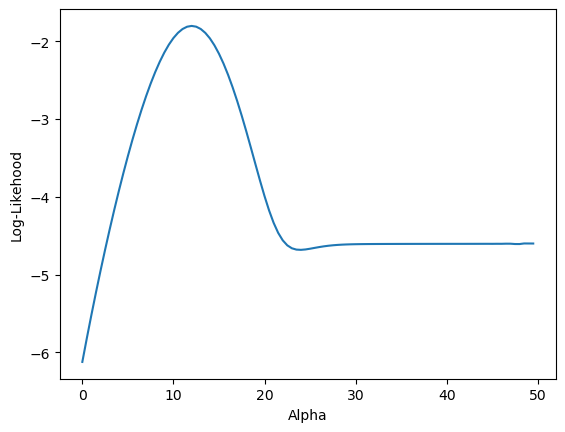

In [11]:
loglikelihoods = []

for a in range(0, 100):

    pi = s ** (a/2)
    pi = pi * 100
    
    transition_matrices = np.array([
        [
            [-(m*(pi[1]/pi[0])), m*(pi[1]/pi[0]), 0, 0, 0, 0, 0, 0, 0, 0],
            [m*(pi[0]/pi[1]), -(m*(pi[0]/pi[1])+m*(pi[2]/pi[1])), m*(pi[2]/pi[1]), 0, 0, 0, 0, 0, 0, 0],
            [0, m*(pi[1]/pi[2]), -(m*(pi[1]/pi[2])+m*(pi[3]/pi[2])), m*(pi[3]/pi[2]), 0, 0, 0, 0, 0, 0],
            [0, 0, m*(pi[2]/pi[3]), -(m*(pi[2]/pi[3])+m*(pi[4]/pi[3])), m*(pi[4]/pi[3]), 0, 0, 0, 0, 0],
            [0, 0, 0, m*(pi[3]/pi[4]), -(m*(pi[3]/pi[4])+m*(pi[5]/pi[4])), m*(pi[5]/pi[4]), 0, 0, 0, 0],
            [0, 0, 0, 0, m*(pi[4]/pi[5]), -(m*(pi[4]/pi[5])+m*(pi[6]/pi[5])), m*(pi[6]/pi[5]), 0, 0, 0],
            [0, 0, 0, 0, 0, m*(pi[5]/pi[6]), -(m*(pi[5]/pi[6])+m*(pi[7]/pi[6])), m*(pi[7]/pi[6]), 0, 0],
            [0, 0, 0, 0, 0, 0, m*(pi[6]/pi[7]), -(m*(pi[6]/pi[7])+m*(pi[8]/pi[7])), m*(pi[8]/pi[7]), 0],
            [0, 0, 0, 0, 0, 0, 0, m*(pi[7]/pi[8]), -(m*(pi[7]/pi[8])+m*(pi[9]/pi[8])), m*(pi[9]/pi[8])],
            [0, 0, 0, 0, 0, 0, 0, 0, m*(pi[8]/pi[9]), -(m*(pi[8]/pi[9]))]
        ]
    ])
    
    like, messages = likelihood_of_tree_penalty(
        parents,
        branch_above,
        ids_asc_time,
        sample_locations_array,
        sample_ids,
        transition_matrices,
        pi
    )
    loglikelihoods.append(like)

plt.plot([a/2 for a in range(0, 100)], loglikelihoods)
plt.xlabel("Alpha")
plt.ylabel("Log-Likehood")
plt.show()

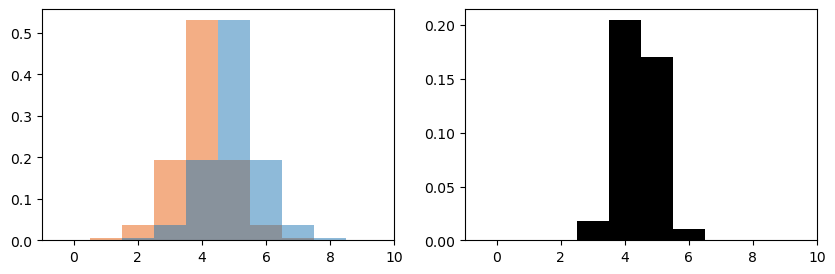

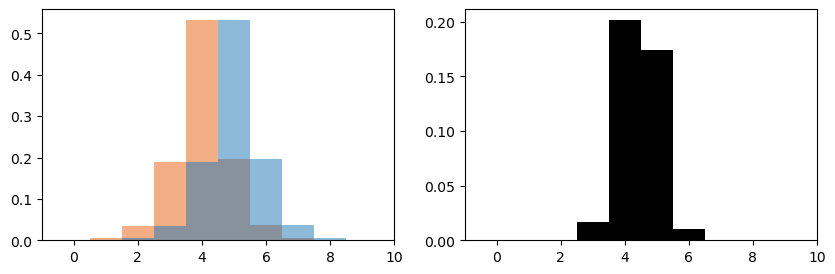

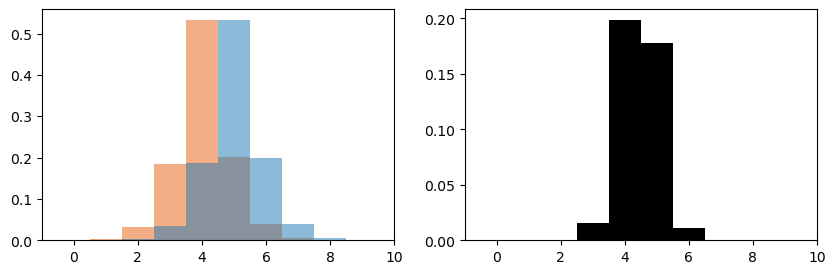

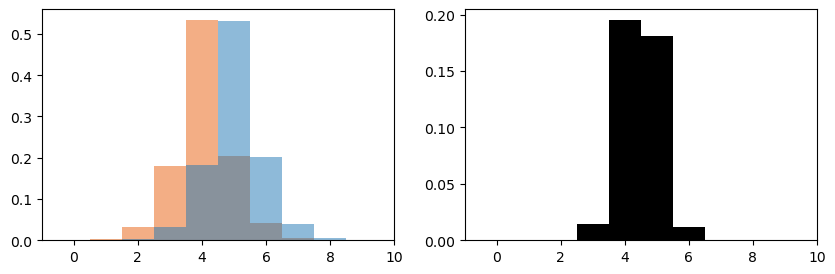

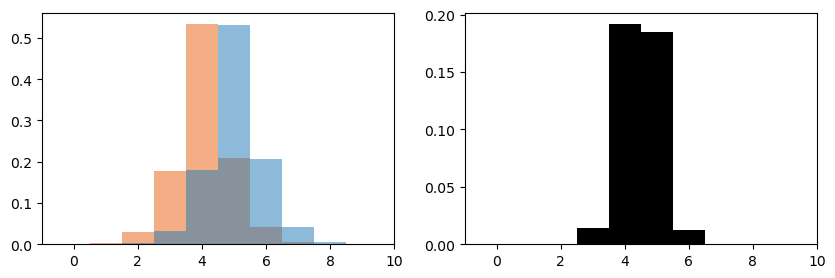

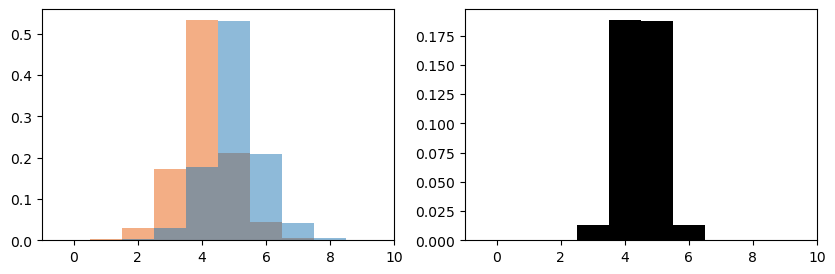

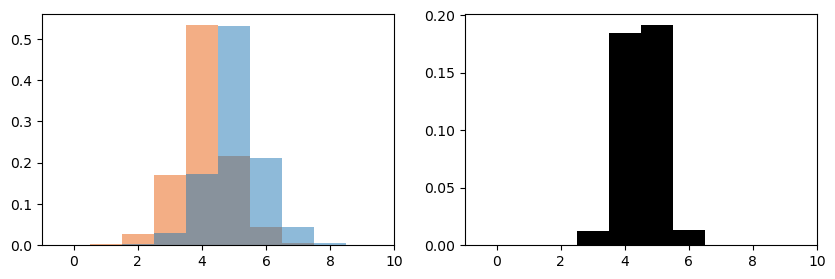

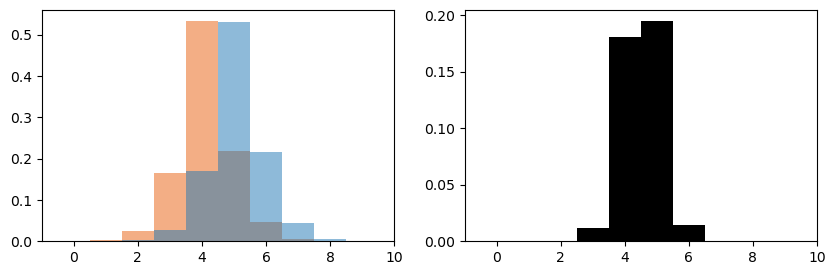

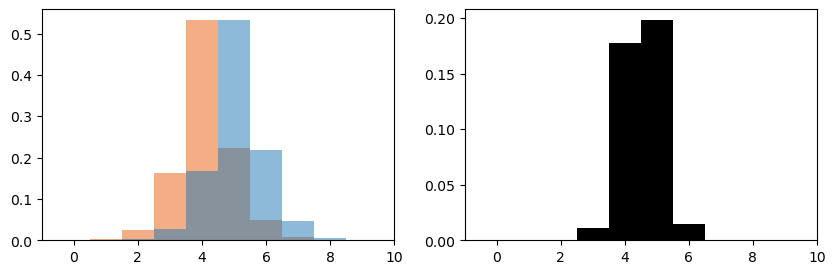

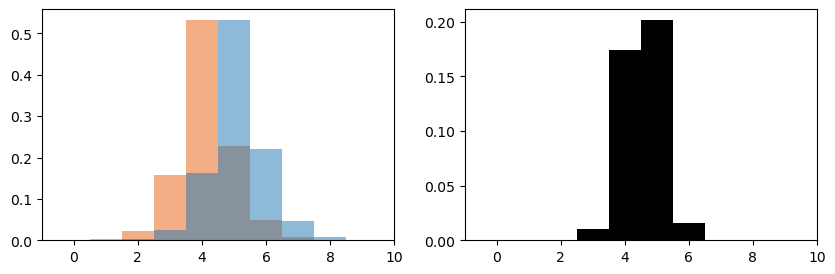

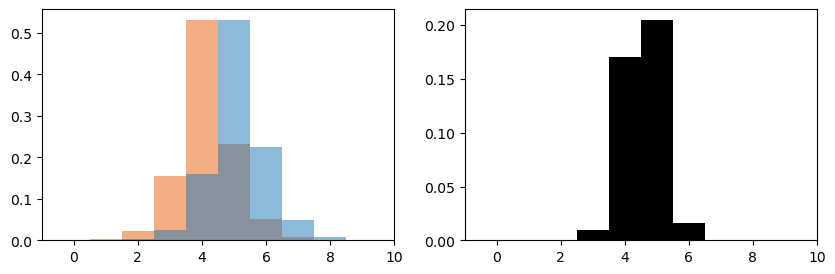

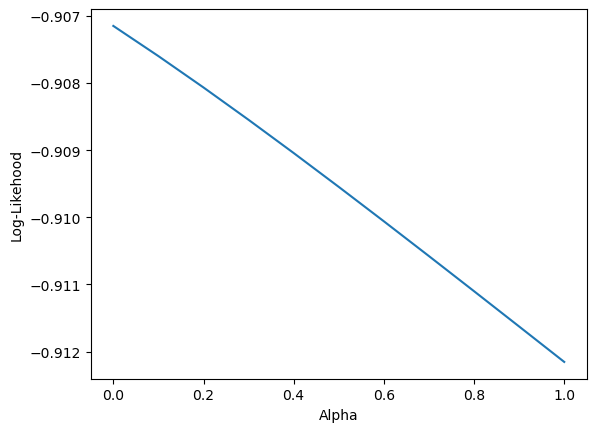

In [14]:
loglikelihoods = []

for a in range(0, 11):

    a = a / 10
    pi = s ** a
    pi = pi
    
    transition_matrices = np.array([
        [
            [-(m*(pi[1]/pi[0])), m*(pi[1]/pi[0]), 0, 0, 0, 0, 0, 0, 0, 0],
            [m*(pi[0]/pi[1]), -(m*(pi[0]/pi[1])+m*(pi[2]/pi[1])), m*(pi[2]/pi[1]), 0, 0, 0, 0, 0, 0, 0],
            [0, m*(pi[1]/pi[2]), -(m*(pi[1]/pi[2])+m*(pi[3]/pi[2])), m*(pi[3]/pi[2]), 0, 0, 0, 0, 0, 0],
            [0, 0, m*(pi[2]/pi[3]), -(m*(pi[2]/pi[3])+m*(pi[4]/pi[3])), m*(pi[4]/pi[3]), 0, 0, 0, 0, 0],
            [0, 0, 0, m*(pi[3]/pi[4]), -(m*(pi[3]/pi[4])+m*(pi[5]/pi[4])), m*(pi[5]/pi[4]), 0, 0, 0, 0],
            [0, 0, 0, 0, m*(pi[4]/pi[5]), -(m*(pi[4]/pi[5])+m*(pi[6]/pi[5])), m*(pi[6]/pi[5]), 0, 0, 0],
            [0, 0, 0, 0, 0, m*(pi[5]/pi[6]), -(m*(pi[5]/pi[6])+m*(pi[7]/pi[6])), m*(pi[7]/pi[6]), 0, 0],
            [0, 0, 0, 0, 0, 0, m*(pi[6]/pi[7]), -(m*(pi[6]/pi[7])+m*(pi[8]/pi[7])), m*(pi[8]/pi[7]), 0],
            [0, 0, 0, 0, 0, 0, 0, m*(pi[7]/pi[8]), -(m*(pi[7]/pi[8])+m*(pi[9]/pi[8])), m*(pi[9]/pi[8])],
            [0, 0, 0, 0, 0, 0, 0, 0, m*(pi[8]/pi[9]), -(m*(pi[8]/pi[9]))]
        ]
    ])
    
    like, messages = likelihood_of_tree_penalty(
        parents,
        branch_above,
        ids_asc_time,
        sample_locations_array,
        sample_ids,
        transition_matrices,
        s
    )

    plot_messages(messages)
    
    loglikelihoods.append(like)

plt.plot([a / 10 for a in range(0, 11)], loglikelihoods)
plt.xlabel("Alpha")
plt.ylabel("Log-Likehood")
plt.show()